In [ ]:
!pip install captum --no-deps

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from torchvision import models
from captum.attr import Saliency, NoiseTunnel, LayerGradCam
import torch.nn.functional as F
import random

# Visual Explanations


Deep learning models achieve strong performance in image classification tasks, but they are often black boxes. Visual explainability methods aim to open these black boxes by highlighting which parts of an image influenced a model’s prediction. Instead of only providing numerical scores or global feature importances, visual XAI techniques generate spatial attribution maps that overlay on the original image, offering intuitive insight into model behavior.

These visual explanations serve several purposes:

- Interpretability: They help humans understand what visual patterns or regions the model considers important.
- Debugging: They reveal when a model is focusing on irrelevant or spurious cues (e.g., background artifacts).
- Trust & validation: In sensitive domains, for example medicine, visual explanations allow practitioners to verify whether a model relies on clinically meaningful features.


In this notebook, we will explore some visual explainable AI techniques on an image classification task using a convolutional neural network (CNN) on an image recognition STL10 dataset.

We will train a simple CNN on a classification of images of 10 categories (airplane, car, cat etc.) and then visualize which regions of the input image contributed most to the model’s classification.
Specifically, we will use several XAI methods:

- Vanilla Saliency
- SmoothGrad
- Integrated Gradients
- Grad-CAM (Gradient-weighted Class Activation Mapping)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
])

train_data = datasets.STL10(root="./data", split='train', download=True, transform=transform)
test_data  = datasets.STL10(root="./data", split='test', download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=1, shuffle=True)

class_names = train_data.classes
print("Classes:", class_names)

Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In order to get predictions that we want to explain, we first create a simple CNN for image classification. It consists of four convolutional layers with ReLU activations, two max-pooling layers to reduce spatial dimensions, and two fully connected layers at the end. The first two convolutional layers extract low-level features and are followed by a pooling layer, while the next two convolutional layers capture higher-level features before another pooling operation.

In [ ]:
# for reproducibility
torch.manual_seed(52)
torch.cuda.manual_seed(52)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()


        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(256 * 24 * 24, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = SimpleCNN().cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
model.train()

for epoch in range(10):
  loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")
  for x, y in loop:
    x, y = x.cuda(), y.cuda()
    optimizer.zero_grad()
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    loop.set_postfix(loss=loss.item())
model.eval()

Epoch 10: 100%|██████████| 79/79 [00:10<00:00,  7.88it/s, loss=0.0819]


SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=147456, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

We will visualise each method in 3 parts: the main image, the heatmap showing which parts of the image contributed the most in the prediction, and an overlay of the heatmap over the image itself for easier understanding. For this reason, we create a helper function, that we can later use for all methods. We select a random image from the dataset and for reproducibility, we set a seed.

In [ ]:
random.seed(43)
idx = random.randint(0, len(test_data) - 1)

example_img, example_label = test_data[idx]

example_img = example_img.unsqueeze(0).cuda()
example_label = torch.tensor([example_label]).cuda()

# enable gradient tracking for gradient-based attribution methods
example_img.requires_grad = True

# helper function to plot all 3: original, heatmap, overlay of the map on the original
def show_heatmap(image, heatmap, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(image.detach().cpu().squeeze().permute(1,2,0))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap='hot')
    plt.title(f"{title} Heatmap")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(image.detach().cpu().squeeze().permute(1,2,0))
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.title(f"{title} Overlay")
    plt.axis('off')

    plt.show()



In [ ]:
with torch.no_grad():
    logits = model(example_img)
    pred_label = logits.argmax(dim=1).item()
    true_label = example_label.item()

print(f"True label: {true_label}")
print(f"Predicted label: {pred_label}")

True label: 0
Predicted label: 0


# Overview of Methods

Now, we can explore different methods to explain model predictions.

The methods can be grouped into:

- Gradient-based methods (Vanilla Saliency, SmoothGrad) – compute derivatives of the predicted score with respect to input pixels.
- Activation-based methods (Grad-CAM) – use the activations of convolutional layers to localize important regions.
- Relevance-based methods (LRP) – propagate the prediction backward through the network to assign relevance scores to each input pixel.

We will first implement some of these methods manually, to understand the mechanics. Later, we will demonstrate Captum, which provides built-in implementations for all of them.

## Vanila Saliency

Vanilla Saliency is the simplest gradient-based explanation method.
This method computes the gradient of the model's score for a target class (or output) with respect to the input pixels. Intuitively, each gradient value measures how a small change in a pixel would change the model's score: large absolute values indicate pixels to which the model's output is most sensitive.

Below we compute the raw gradients, take absolute values (or squared values), and aggregate across channels to obtain a single 2D saliency map that we visualise on top of the original image.


How it works:

1. Take a trained model and a single input image.
2. Compute the gradient of the score for the predicted class with respect to each input pixel.
3. This gradient indicates how much a small change in each pixel would affect the class score.
4. Larger magnitudes correspond to pixels that strongly influence the prediction.


Advantages: Simple and fast.

Limitations: Noisy and sometimes highlights irrelevant pixels.

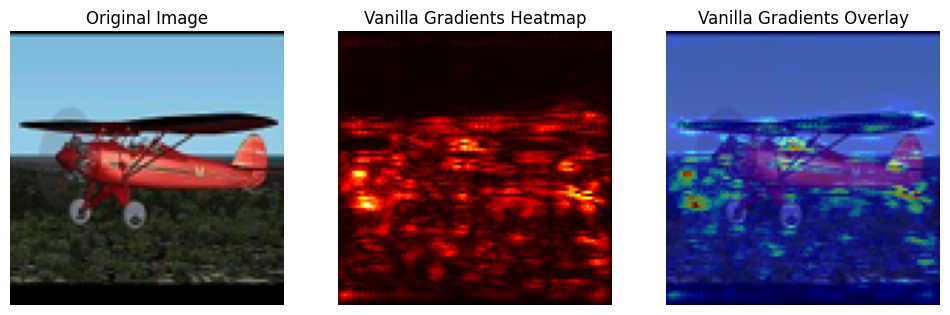

In [ ]:
# Option 1

logits = model(example_img)
score = logits[0, example_label]
score.backward()

vanilla_saliency = example_img.grad.data.abs().squeeze()
vanilla_saliency = vanilla_saliency.max(dim=0)[0]  # max over RGB channels
vanilla_saliency = vanilla_saliency.detach().cpu().numpy()

show_heatmap(example_img, vanilla_saliency, "Vanilla Gradients")


# Option 2: use built-in function from captum

# saliency = Saliency(model)
# vanilla_attr = saliency.attribute(example_img, target=example_label.item())
# vanilla_attr = vanilla_attr.squeeze().detach().cpu().numpy().max(axis=0)

# show_heatmap(example_img, vanilla_attr, "Vanilla Gradients")


## SmoothGrad

SmoothGrad is an extension of vanilla saliency designed to reduce noise and produce clearer, more interpretable saliency maps.
Instead of computing gradients on a single input, SmoothGrad averages the gradients from many noisy versions of the same image. The added noise helps cancel out fluctuations, resulting in a smoother and more stable explanation.

Below we repeatedly add small Gaussian noise to the input, compute gradients for each noisy sample, and then average the absolute (or squared) gradients to obtain a cleaner 2D saliency map.

How it works:

1. Start with a trained model and a single input image.
2. Add small random noise (e.g., Gaussian) to the image multiple times.
3. For each noisy sample, compute the gradient of the target class score w.r.t. the input pixels.
4. Average all gradient maps to obtain a smoother, denoised saliency map.

Advantages: Much smoother maps, reduces gradient noise, highlights more stable features.

Limitations: Requires multiple forward/backward passes; still inherits limitations of raw gradients.

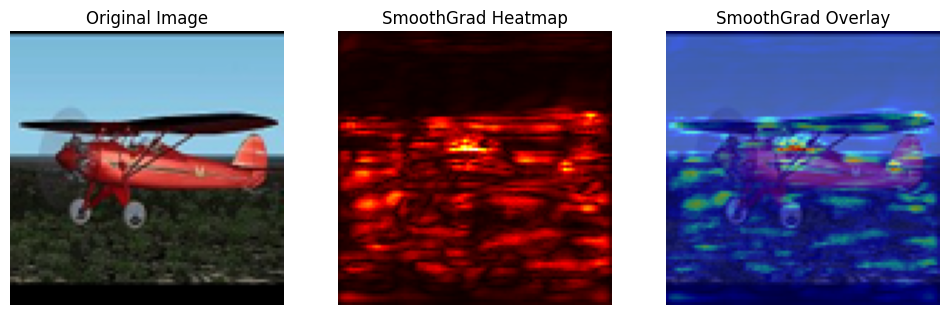

In [ ]:
# Option 1: under-the hood function for smooth grad
def smooth_grad(model, image, label, n_samples=200, stdev=0.2):
    model.zero_grad()
    grads = []
    for _ in range(n_samples):
        noise = torch.randn_like(image) * stdev
        noisy_image = (image + noise).clone().detach()
        noisy_image.requires_grad = True
        output = model(noisy_image)
        score = output[0, label]
        score.backward()
        grads.append(noisy_image.grad.data.cpu().numpy())

    # Convert list to array (n_samples, 1, 3, H, W)
    grads = np.array(grads)
    avg_grads = np.mean(grads, axis=0)[0]  # remove batch dim, shape (3,H,W)

    # Reduce channels to single 2D map
    saliency = np.abs(avg_grads).max(axis=0)  # shape (H,W)

    # Normalize
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency

smooth_saliency = smooth_grad(model, example_img, example_label.item(), n_samples=100, stdev=0.2)

# Show SmoothGrad
show_heatmap(example_img, smooth_saliency, "SmoothGrad")


# Option 2: built-in from captum

# saliency = Saliency(model)
# nt = NoiseTunnel(saliency)
# smooth_attr = nt.attribute(
#     example_img,
#     nt_type='smoothgrad',    # specify SmoothGrad
#     target=example_label.item(),
#     stdevs=0.2,              # note: plural 'stdevs'
#     nt_samples=200            # note: plural 'nt_samples'
# )
# smooth_attr = smooth_attr.squeeze().detach().cpu().numpy().max(axis=0)
# show_heatmap(example_img, smooth_attr, "SmoothGrad")



## Integrated Gradients

Integrated Gradients addresses the problem of gradient saturation and noisy/unstable explanations by computing path-integrated gradients from a baseline image (e.g., all zeros) to the original input.
Instead of using a single gradient, it accumulates gradients along a straight-line interpolation path from baseline -> input, capturing how the model’s prediction changes as features are gradually added.

Below we generate interpolated images between the baseline and the input, compute gradients at each step, and average them to produce a more reliable attribution map.

How it works:
1. Choose a baseline image (often all zeros or blurred input).
2. Create a sequence of images interpolating from baseline to the real input.
3. For each step, compute the gradient of the target score w.r.t. the interpolated input.
4. Average these gradients and multiply by the input–baseline difference to obtain pixel-level attributions.

Advantages: Theoretically grounded, reduces noise, avoids gradient saturation, satisfies desirable axioms (e.g., completeness).

Limitations: More computationally expensive; requires selecting a suitable baseline.

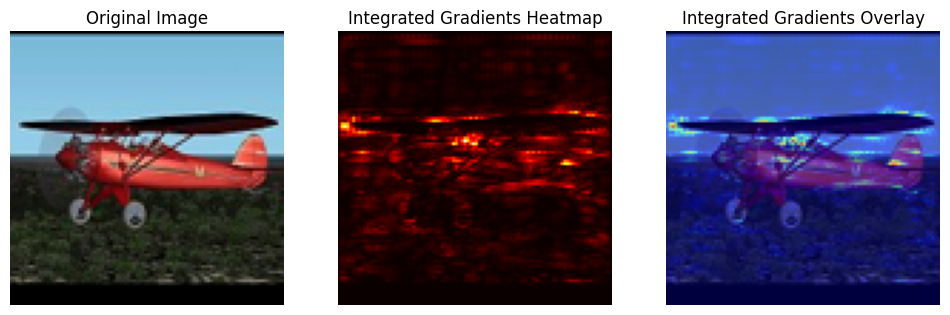

In [ ]:
def integrated_gradients(model, image, label, baseline=None, steps=300):
    if baseline is None:
        baseline = torch.zeros_like(image).cuda()  # black baseline

    # Scale inputs from baseline -> image
    scaled_inputs = [
        baseline + (float(i) / steps) * (image - baseline)
        for i in range(steps + 1)
    ]

    grads = []
    for scaled in scaled_inputs:
        scaled = scaled.clone().detach().requires_grad_(True)
        output = model(scaled)
        score = output[0, label]
        model.zero_grad()
        score.backward()
        grads.append(scaled.grad.data.cpu().numpy())

    grads = np.array(grads)
    avg_grads = grads.mean(axis=0)[0]  # (3,H,W)

    # Integrated gradients = average gradients * input difference
    ig = (image.detach().cpu().numpy()[0] - baseline.detach().cpu().numpy()[0]) * avg_grads

    ig = np.abs(ig).max(axis=0)  # reduce RGB channels

    # Normalize
    ig = (ig - ig.min()) / (ig.max() - ig.min() + 1e-8)
    return ig

ig_map = integrated_gradients(model, example_img, example_label.item(), steps=100)

show_heatmap(example_img, ig_map, "Integrated Gradients")



## GradCAM

Grad-CAM (Gradient-weighted Class Activation Mapping) produces coarse, spatially consistent heatmaps by using gradients flowing into the last convolutional layer instead of gradients w.r.t. the input pixels.
This helps identify which regions of the image are important for a prediction, capturing higher-level semantic features rather than pixel-level noise.

Below we compute the gradient of the target class score w.r.t. feature maps in the final convolutional layer, average them to obtain importance weights, and combine these with the feature maps to generate a class-discriminative heatmap.

How it works:
1. Forward pass through the network to compute the predicted score.
2. Identify a target convolutional layer (usually the last one).
3. Register hooks to save:
- Activations of the target layer
- Gradients of the score w.r.t. the activations
4. Compute channel weights by taking the global average of the gradients over spatial dimensions.
5. Multiply each channel’s activation by its weight and sum across channels → produces a coarse localization map.
6. Apply ReLU to keep only positive contributions.
7. Upsample the resulting heatmap to the input image size.


Advantages: Produces interpretable, high-level, class-discriminative heatmaps; robust and widely used.

Limitations: Only highlights regions, not individual pixels, and depends on the choice of convolutional layer.

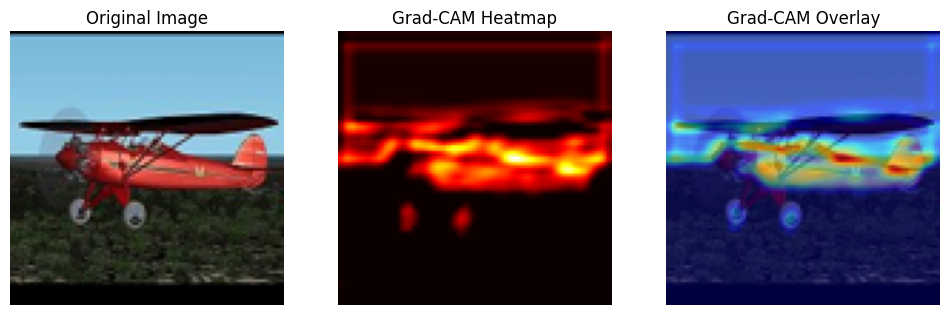

In [ ]:
# Option 1: under-the-hood GradCAM

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx):
        self.model.zero_grad()
        output = self.model(x)
        score = output[0, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

grad_cam = GradCAM(model, model.conv4)
cam = grad_cam(example_img, example_label.item())
show_heatmap(example_img, cam, "Grad-CAM")


# Option 2: built-in from captum

# layer_gc = LayerGradCam(model, model.conv4)
# gradcam_attr = layer_gc.attribute(example_img, target=example_label.item())
# gradcam_attr = F.relu(gradcam_attr)
# gradcam_attr = F.interpolate(gradcam_attr, size=(example_img.shape[2], example_img.shape[3]),
#                              mode='bilinear', align_corners=False)
# gradcam_attr = gradcam_attr.squeeze().detach().cpu().numpy()
# gradcam_attr = (gradcam_attr - gradcam_attr.min()) / (gradcam_attr.max() - gradcam_attr.min() + 1e-8)


# show_heatmap(example_img, gradcam_attr, "Grad-CAM")


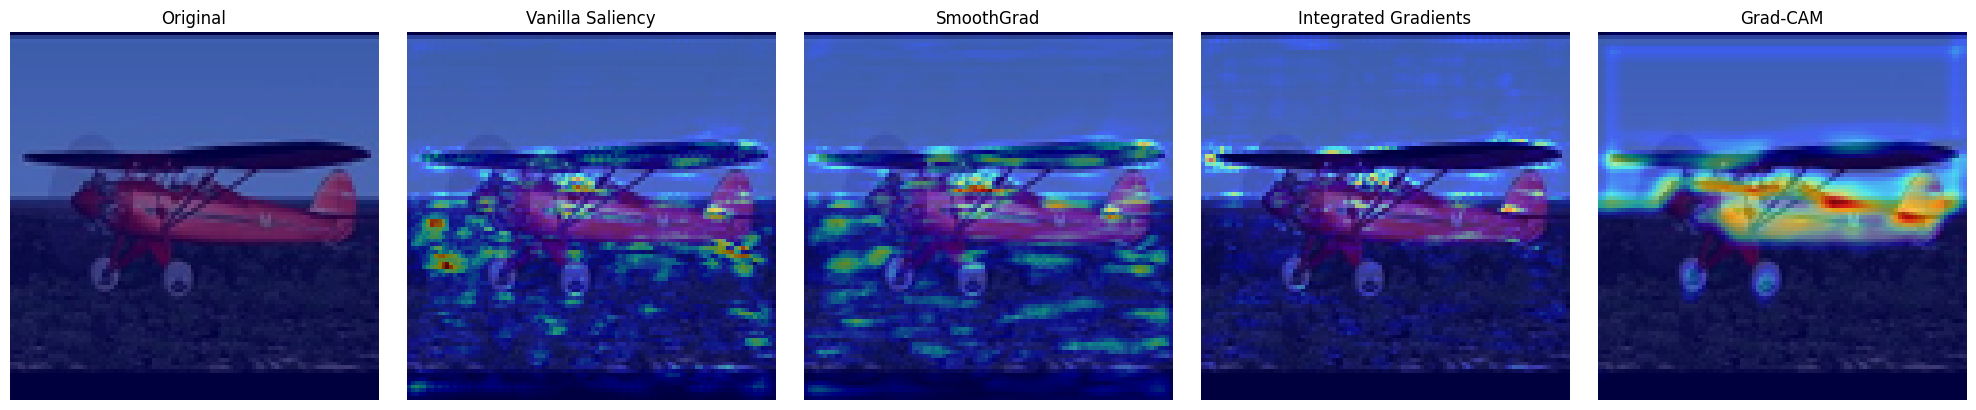

In [ ]:
def show_overlay(img, saliency, title):
    """
    Overlay saliency map on top of an image.
    img: tensor of shape (C,H,W) or (1,C,H,W)
    saliency: 2D numpy array of shape (H,W)
    """
    # If batch dimension exists, select first item
    if img.ndim == 4:
        img = img[0]

    if torch.is_tensor(img):
        img = img.detach().cpu().numpy()

    # Convert (C,H,W) -> (H,W,3) if RGB
    if img.ndim == 3:
        if img.shape[0] == 1:   # grayscale
            img = img[0]
        elif img.shape[0] == 3: # RGB
            img = img.transpose(1,2,0)

    plt.imshow(img, cmap='gray')
    plt.imshow(saliency, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.title(title)

def normalize(x):
    x = np.maximum(x, 0)
    x = x / (x.max() + 1e-8)
    return x

vanilla_map_norm    = normalize(vanilla_saliency)
smoothgrad_map_norm = normalize(smooth_saliency)
ig_map_norm         = normalize(ig_map)
gradcam_map_norm    = normalize(cam)

plt.figure(figsize=(20, 4))

# Original
plt.subplot(1,5,1)
show_overlay(example_img, np.zeros_like(vanilla_map_norm), "Original")

# Vanilla
plt.subplot(1,5,2)
show_overlay(example_img, vanilla_map_norm, "Vanilla Saliency")

# SmoothGrad
plt.subplot(1,5,3)
show_overlay(example_img, smoothgrad_map_norm, "SmoothGrad")

# Integrated Gradients
plt.subplot(1,5,4)
show_overlay(example_img, ig_map_norm, "Integrated Gradients")

# Grad-CAM
plt.subplot(1,5,5)
show_overlay(example_img, gradcam_map_norm, "Grad-CAM")

plt.tight_layout()
plt.show()


## Missclassified sample
We showed maps for a sample that was classified correctly. Let's now try to find a missclassified sample and visualize Grad-CAM.

Found misclassified sample: True=7, Pred=2


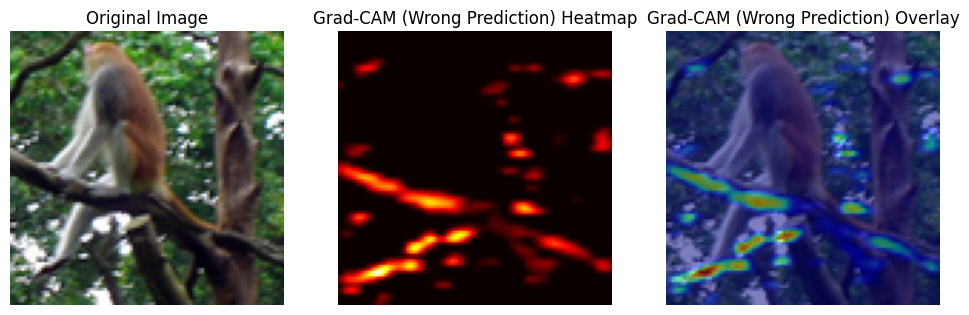

In [ ]:
# def find_misclassified(model, dataset):
#     model.eval()
#     for i in range(len(dataset)):
#         img, true_label = dataset[i]
#         img_cuda = img.unsqueeze(0).cuda()

#         with torch.no_grad():
#             pred_label = model(img_cuda).argmax().item()

#         if pred_label != true_label:
#             return i, img, true_label, pred_label

#     return None

random.seed(42)
def get_random_misclassified(model, dataset):
    model.eval()
    misclassified = []

    # Collect all misclassified samples
    for i in range(len(dataset)):
        img, true_label = dataset[i]
        img_cuda = img.unsqueeze(0).cuda()

        with torch.no_grad():
            pred_label = model(img_cuda).argmax().item()

        if pred_label != true_label:
            misclassified.append((i, img, true_label, pred_label))

    if len(misclassified) == 0:
        return None  # No misclassifications found

    # Pick one randomly
    return random.choice(misclassified)



idx, wrong_img, true_label, pred_label = get_random_misclassified(model, test_data)

print(f"Found misclassified sample: True={true_label}, Pred={pred_label}")

wrong_img = wrong_img.unsqueeze(0).cuda()
wrong_img.requires_grad = True

logits = model(wrong_img)
score = logits[0, pred_label]
model.zero_grad()
score.backward()

wrong_cam = grad_cam(wrong_img, pred_label)
show_heatmap(wrong_img, wrong_cam, "Grad-CAM (Wrong Prediction)")


## Quantitative Comparison
We can compare these methods quantitatively using three complementary metrics. This allows us to go beyond visual inspection and measure how similar the explanations are in a rigorous way.

- Pearson Correlation: Measures the linear relationship between two saliency maps. A higher value indicates that regions highlighted by one method tend to be highlighted by the other.

- Structural Similarity Index (SSIM): Captures perceptual similarity between two heatmaps, taking into account structure, contrast, and texture. Higher SSIM means the maps are visually more alike.

- Intersection over Union (IoU) of Top-k Pixels: Measures overlap of the most salient regions (top 20% by default). It quantifies whether different methods focus on the same “important” areas of the image.


In [ ]:
from skimage.metrics import structural_similarity as ssim
import itertools

def compare_saliency_maps(map1, map2, threshold=0.2):
    """Compare two 2D saliency maps: Pearson, SSIM, IoU on top-k pixels"""
    metrics = {}

    # Flatten for Pearson
    metrics['pearson'] = np.corrcoef(map1.flatten(), map2.flatten())[0,1]

    # SSIM (specify data_range for float images)
    metrics['ssim'] = ssim(map1, map2, data_range=1.0)

    # IoU on thresholded maps
    t1 = map1 > np.percentile(map1, 100*(1-threshold))
    t2 = map2 > np.percentile(map2, 100*(1-threshold))
    intersection = np.logical_and(t1, t2).sum()
    union = np.logical_or(t1, t2).sum()
    metrics['iou'] = intersection / (union + 1e-8)

    return metrics


# Put all normalized maps in a dict
saliency_maps = {
    'Vanilla': vanilla_map_norm,
    'SmoothGrad': smoothgrad_map_norm,
    'IG': ig_map_norm,
    'Grad-CAM': gradcam_map_norm
}

# Compute pairwise metrics
print("Saliency Map Pairwise Comparison:\n")
for (name1, map1), (name2, map2) in itertools.combinations(saliency_maps.items(), 2):
    metrics = compare_saliency_maps(map1, map2, threshold=0.2)
    print(f"{name1} vs {name2}: Pearson={metrics['pearson']:.3f}, SSIM={metrics['ssim']:.3f}, IoU={metrics['iou']:.3f}\n")


Saliency Map Pairwise Comparison:

Vanilla vs SmoothGrad: Pearson=0.771, SSIM=0.480, IoU=0.461

Vanilla vs IG: Pearson=0.538, SSIM=0.439, IoU=0.273

Vanilla vs Grad-CAM: Pearson=0.303, SSIM=0.161, IoU=0.272

SmoothGrad vs IG: Pearson=0.582, SSIM=0.334, IoU=0.317

SmoothGrad vs Grad-CAM: Pearson=0.402, SSIM=0.119, IoU=0.347

IG vs Grad-CAM: Pearson=0.422, SSIM=0.196, IoU=0.365



## Summary

Visual explanation methods provide insight into which regions of an image most strongly influence a model’s prediction, offering an intuitive way to evaluate whether the model is focusing on meaningful structures.

Vanilla Gradients offer the most direct approach by computing the gradient of the output with respect to the input pixels. While simple and efficient, the resulting saliency maps can be noisy and unstable due to sensitivity to small input perturbations.

SmoothGrad addresses this issue by averaging gradients across multiple noisy samples of the input. This leads to clearer, less fragmented saliency maps and helps highlight more reliable regions of importance, making it easier to interpret fine-grained structures such as the boundaries of lesions or nodules.

Integrated Gradients provide a more principled solution by accumulating gradients along a path from a baseline image to the actual input. This method addresses gradient saturation and produces more faithful attributions. As a result, IG is often more stable across samples, making it particularly useful for identifying subtle but important features in medical images.

Grad-CAM, uses the model’s convolutional feature maps, producing coarse but intuitive heatmaps that reveal which spatial regions the network activates at deeper layers. This makes it especially effective for highlighting broader areas or classification-level cues, even if it lacks the pixel-level resolution of gradient-based methods.

- Together, these methods complement one another:
- Vanilla Gradients for direct sensitivity,
- SmoothGrad for denoised local relevance,
- Integrated Gradients for principled and stable attributions
- Grad-CAM for high-level region-based understanding.

Using multiple saliency approaches allows for cross-validation of explanations, increasing confidence in the model’s reasoning and helping identify potential failure modes or biases in visual attention patterns.